# Деревья решений

## Решение задачи классификации

In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Создаём сложный датасет
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=4,
    n_clusters_per_class=1,
    class_sep=0.5,
    random_state=42
)

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# Инициализация дерева
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
print(f"Accuracy: {clf.score(X_test, y_test):.2f}")

Accuracy: 0.66


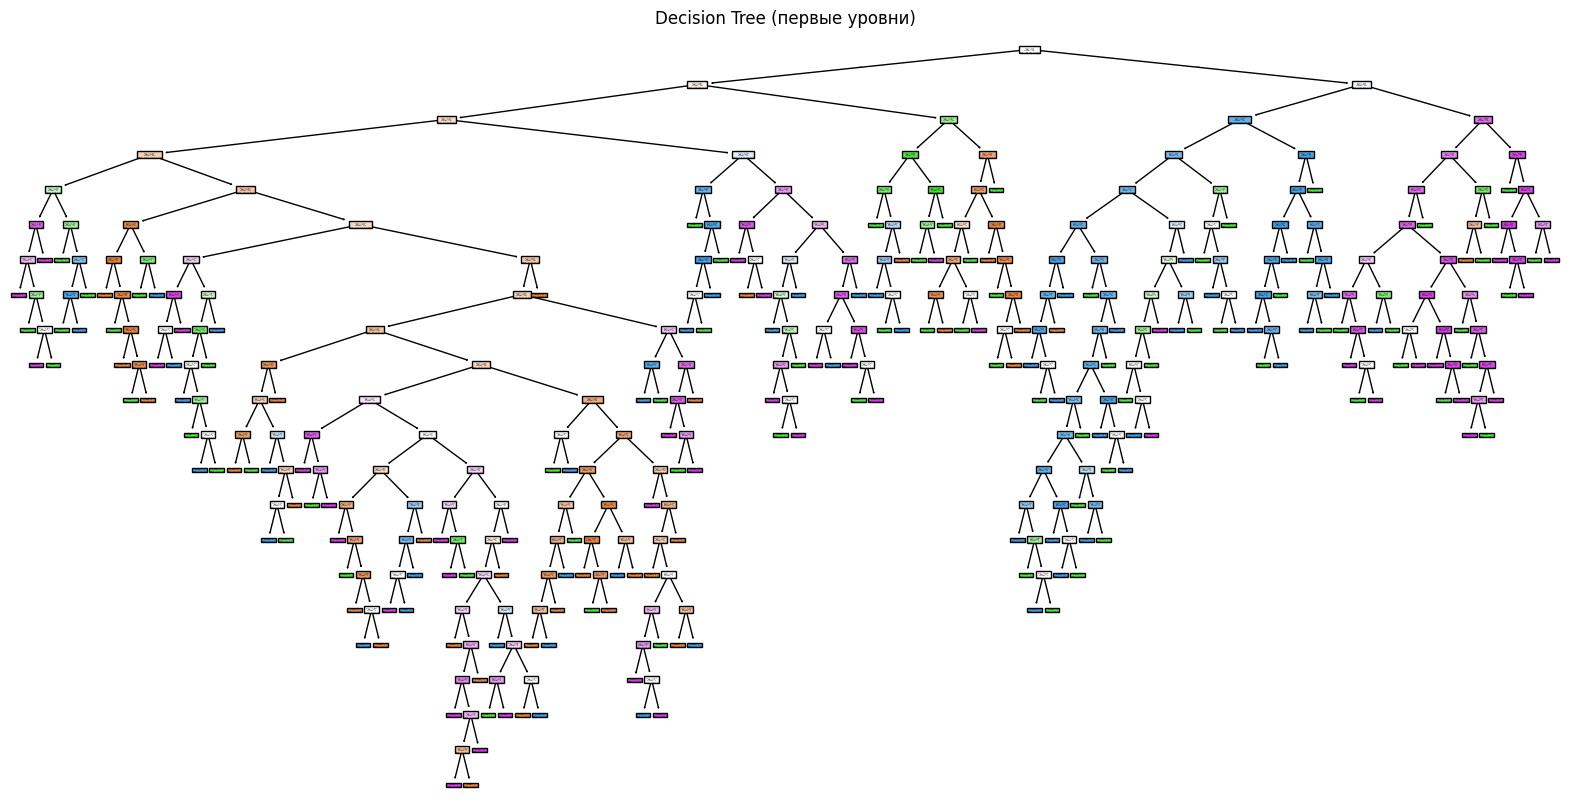

In [2]:
plt.figure(figsize=(20, 10))
plot_tree(clf, filled=True)
plt.title("Decision Tree (первые уровни)")
plt.show()

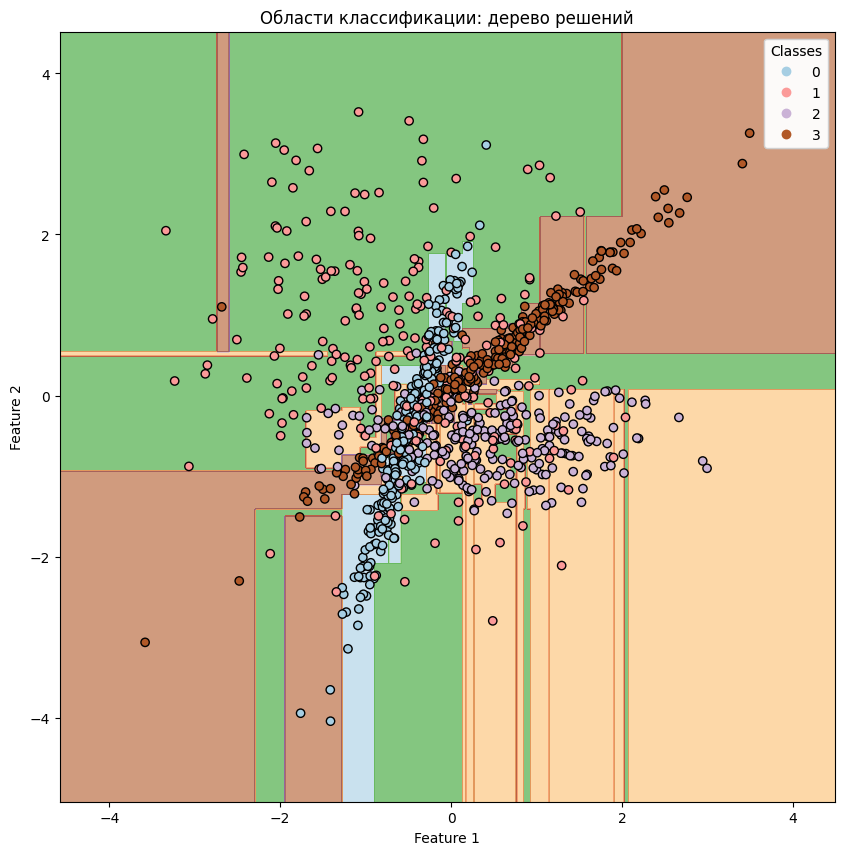

In [3]:
# Визуализация областей классификации
def plot_decision_boundaries(model, X, y, ax=None, title="Decision Boundaries"):
    if ax is None:
        ax = plt.gca()
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.6, cmap=plt.cm.Paired)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", cmap=plt.cm.Paired)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    legend = ax.legend(*scatter.legend_elements(), loc="upper right", title="Classes")
    ax.add_artist(legend)

# Построение графика областей классификации
plt.figure(figsize=(10, 10))
plot_decision_boundaries(clf, X, y)
plt.title("Области классификации: дерево решений")
plt.show()

## Pre-pruning

In [4]:
clf_prepruned = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
clf_prepruned.fit(X_train, y_train)

print(f"Accuracy (pre-pruned): {clf_prepruned.score(X_test, y_test):.2f}")

Accuracy (pre-pruned): 0.68


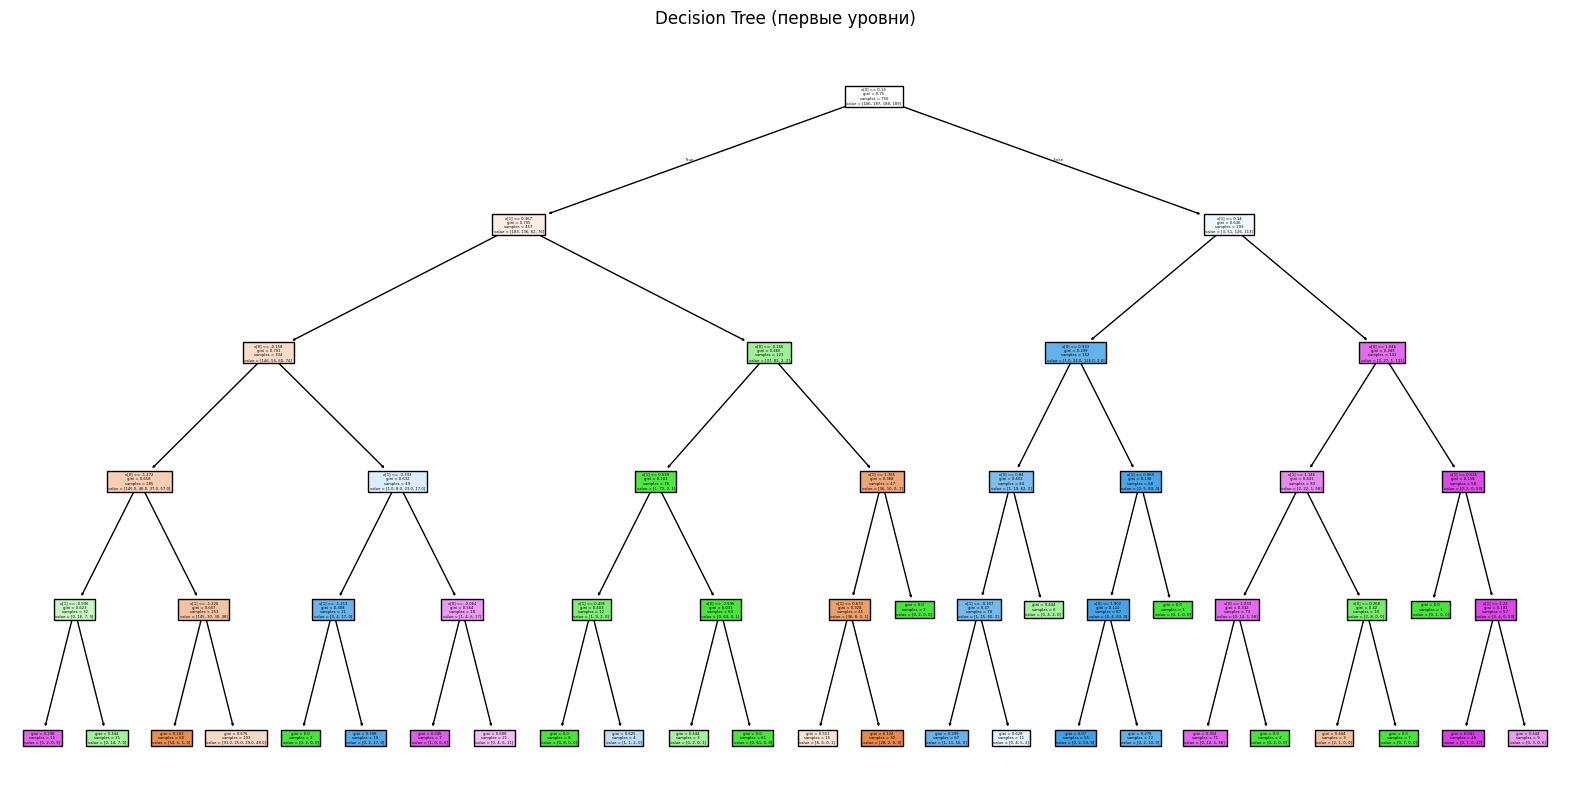

In [5]:
plt.figure(figsize=(20, 10))
plot_tree(clf_prepruned, filled=True)
plt.title("Decision Tree (первые уровни)")
plt.show()

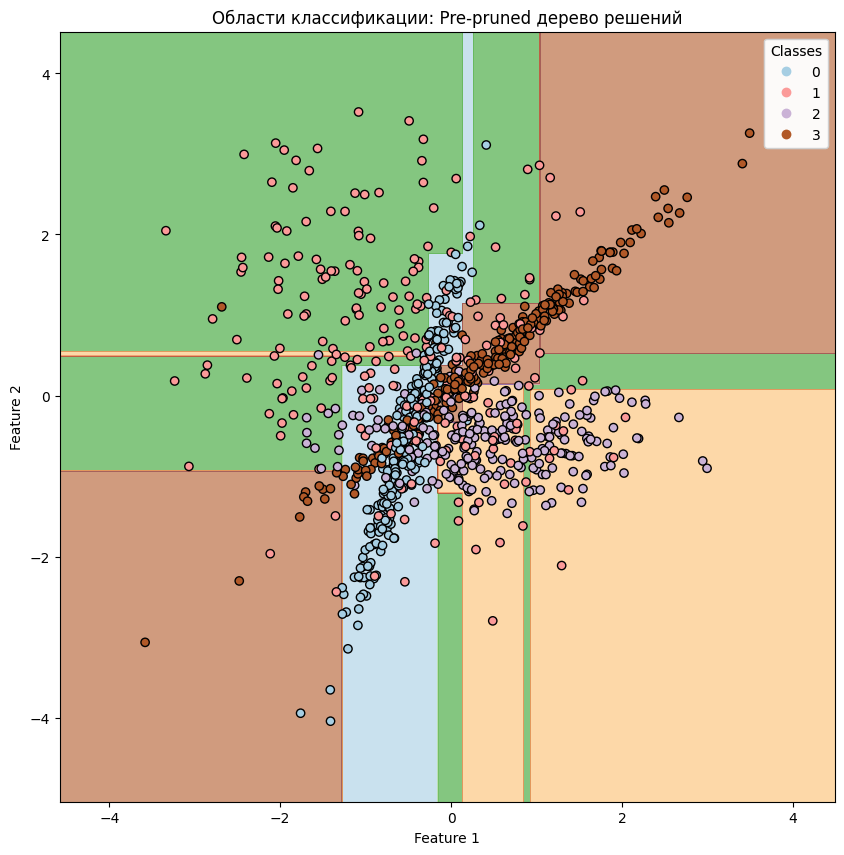

In [6]:
plt.figure(figsize=(10, 10))
plot_decision_boundaries(clf_prepruned, X, y)
plt.title("Области классификации: Pre-pruned дерево решений")
plt.show()

## Post-pruning

In [7]:
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Тестируем несколько деревьев с разными alpha
clfs = [DecisionTreeClassifier(random_state=42, ccp_alpha=alpha).fit(X_train, y_train) for alpha in ccp_alphas]

# Оцениваем на тесте
test_scores = [clf.score(X_test, y_test) for clf in clfs]

# Выбираем лучшее
best_index = np.argmax(test_scores)
best_alpha = ccp_alphas[best_index]
print(f"Best alpha: {best_alpha:.4f}, Accuracy: {test_scores[best_index]:.2f}")

Best alpha: 0.0070, Accuracy: 0.73


In [8]:
clf_postpruned = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha).fit(X_train, y_train)

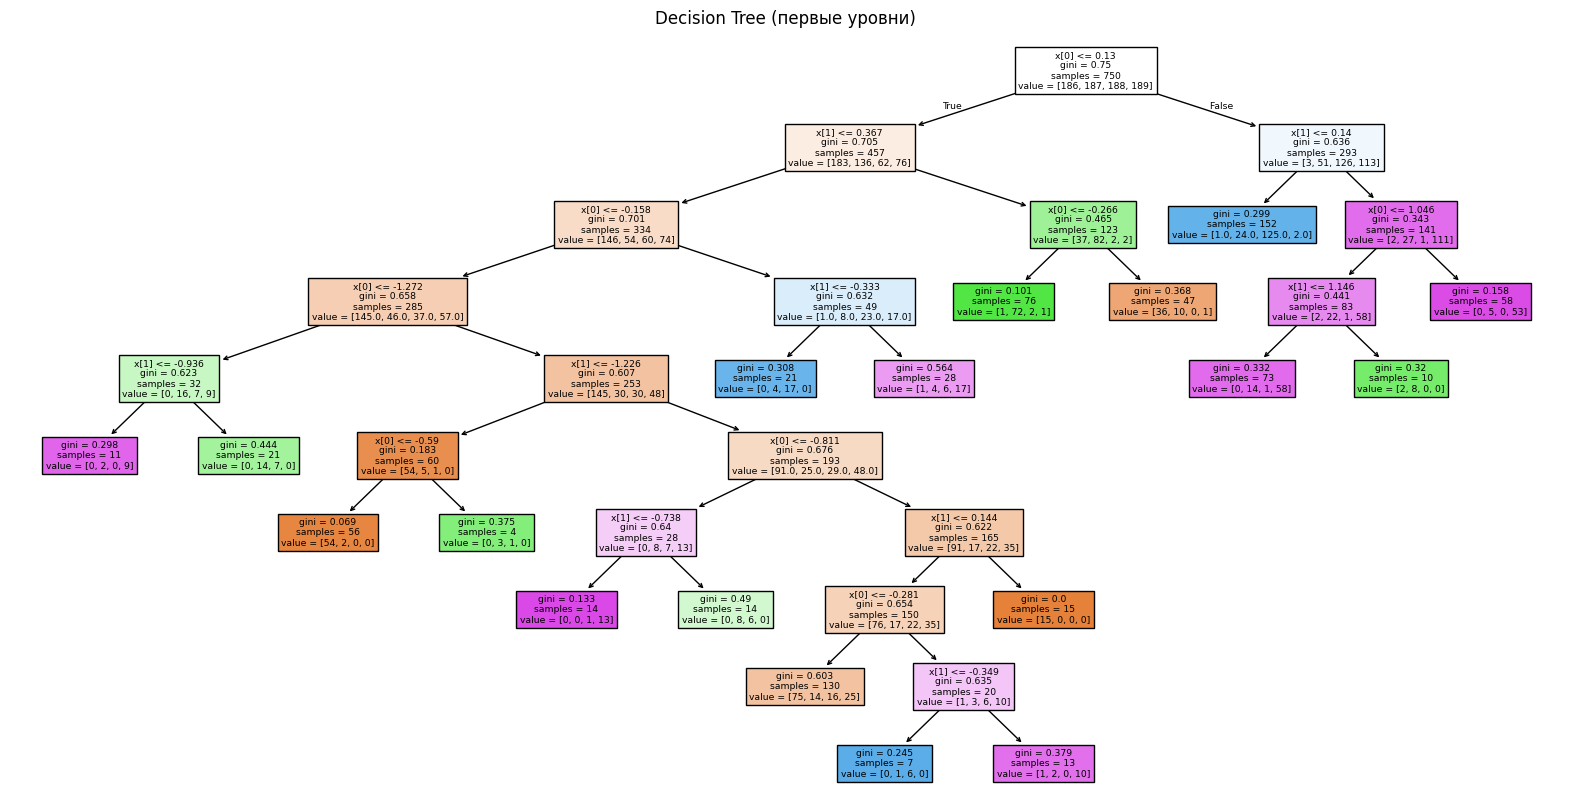

In [9]:
plt.figure(figsize=(20, 10))
plot_tree(clf_postpruned, filled=True)
plt.title("Decision Tree (первые уровни)")
plt.show()

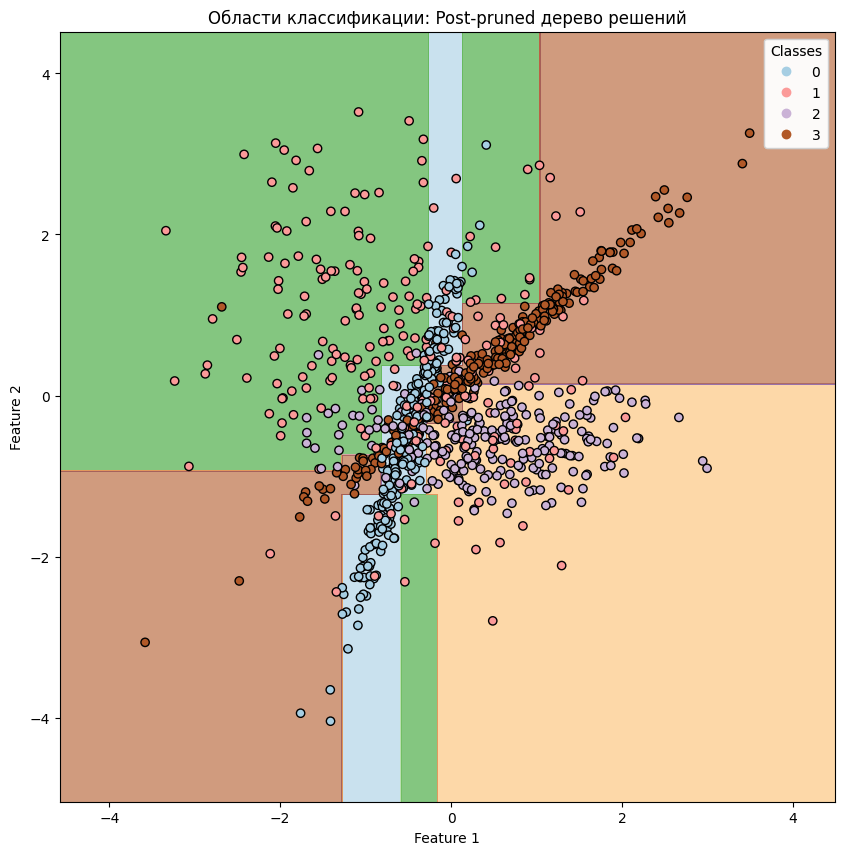

In [10]:
plt.figure(figsize=(10, 10))
plot_decision_boundaries(clf_postpruned, X, y)
plt.title("Области классификации: Post-pruned дерево решений")
plt.show()

## Поиск по сетке лучших гиперпараметров (поиск лучшей регуляризации)

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [1, 2, 5, 10, 15, None],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_leaf_nodes': [None, 10, 20, 30, 50]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best accuracy: {grid_search.best_score_:.2f}")

Best params: {'max_depth': 10, 'max_leaf_nodes': 30, 'min_samples_leaf': 1}
Best accuracy: 0.74


In [12]:
best_clf = grid_search.best_estimator_

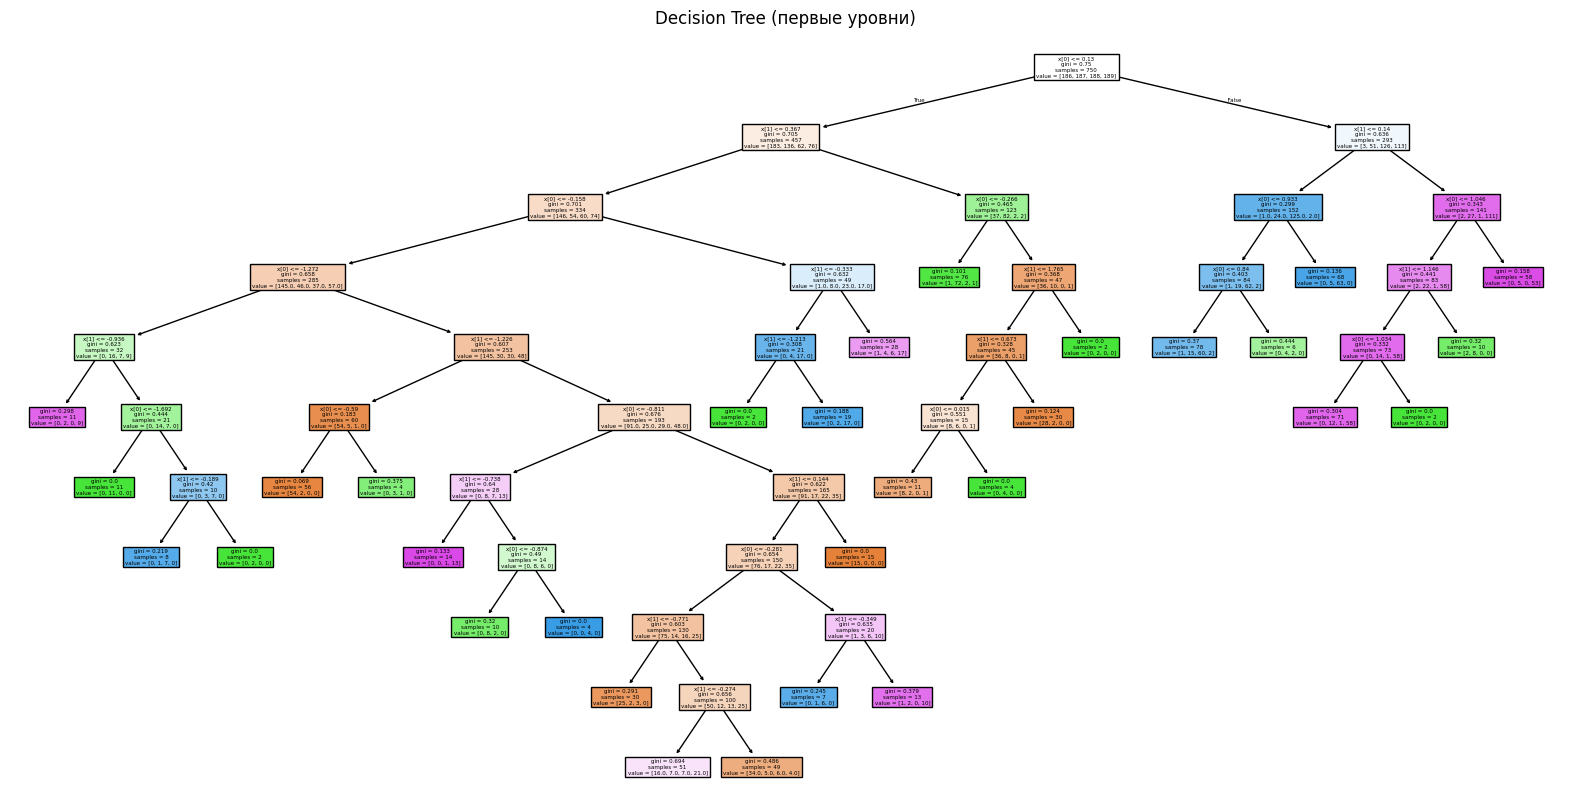

In [13]:
plt.figure(figsize=(20, 10))
plot_tree(best_clf, filled=True)
plt.title("Decision Tree (первые уровни)")
plt.show()

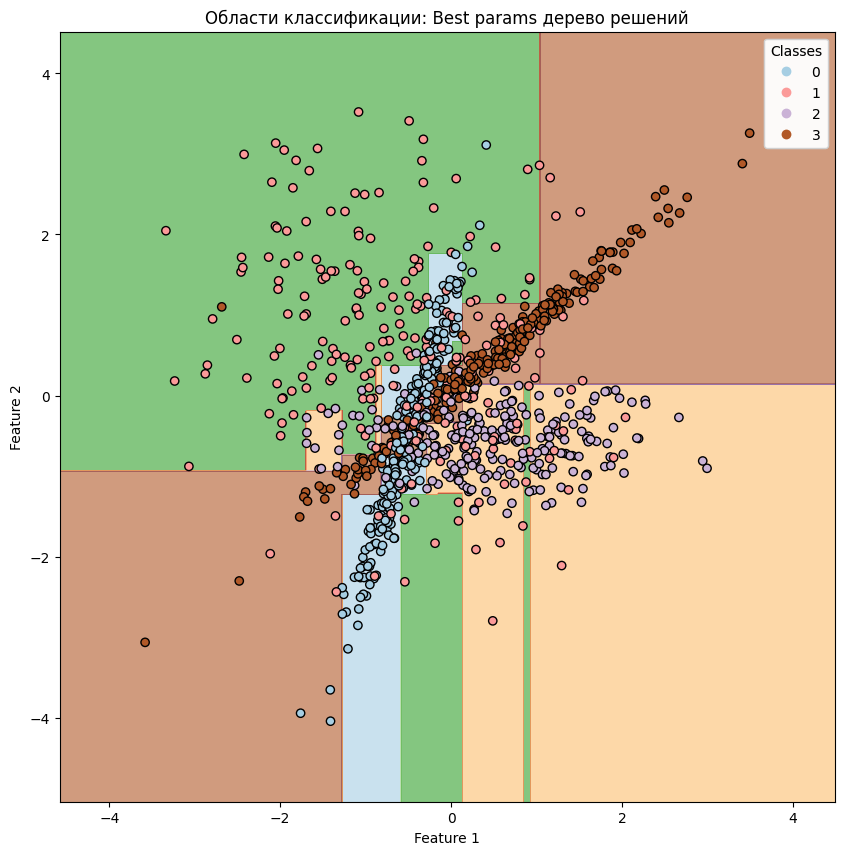

In [14]:
plt.figure(figsize=(10, 10))
plot_decision_boundaries(best_clf, X, y)
plt.title("Области классификации: Best params дерево решений")
plt.show()

## Работа с пропусками

In [15]:
import pandas as pd

# Создаем копию и добавим пропуски
X_missing = X.copy()
rng = np.random.RandomState(42)
missing_mask = rng.rand(*X_missing.shape) < 0.1
X_missing[missing_mask] = np.nan

# Обучим дерево на данных с пропущенными значениями после простой обработки
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_missing)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_imputed, y, stratify=y, random_state=42)

clf_postpruned.fit(X_train_m, y_train_m)

print(f"Accuracy with missing values: {clf_postpruned.score(X_test_m, y_test_m):.2f}")

Accuracy with missing values: 0.63


In [16]:
pd.DataFrame(X_missing).sample(10, random_state=40)

,0,1
204,-0.175861,NaN
71,0.033544,0.778521
594,1.284577,-0.716192
672,2.174701,-0.528312
14,1.382030,NaN
64,NaN,0.053602
340,-0.686766,-1.184090
135,0.439899,0.302905
350,1.741449,NaN
976,-0.469268,-0.036559


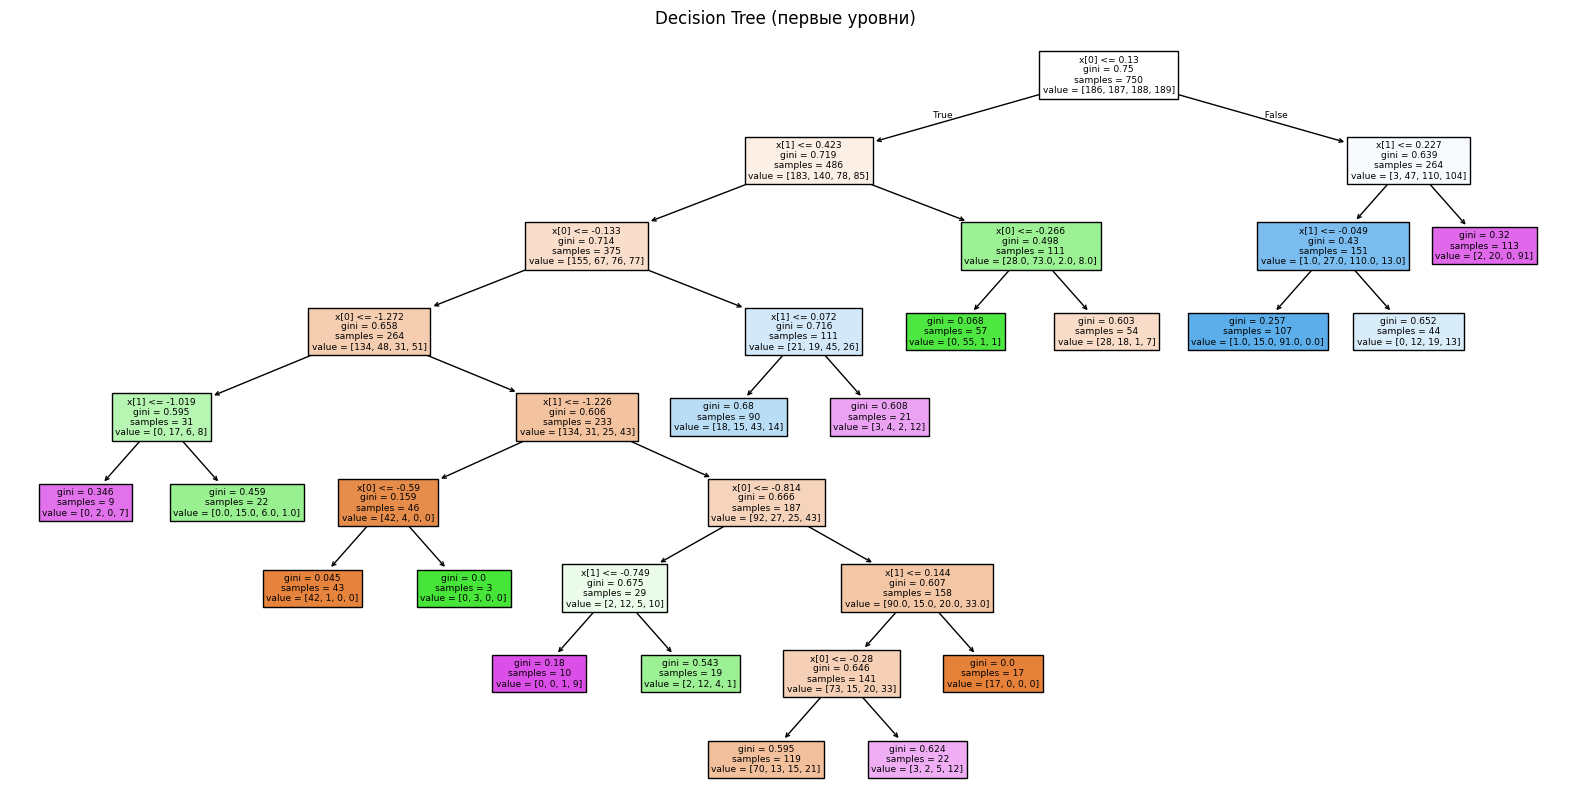

In [17]:
plt.figure(figsize=(20, 10))
plot_tree(clf_postpruned, filled=True)
plt.title("Decision Tree (первые уровни)")
plt.show()

## Неустойчивость дерева

ДЕМОНСТРАЦИЯ НЕУСТОЙЧИВОСТИ ДЕРЕВЬЕВ РЕШЕНИЙ


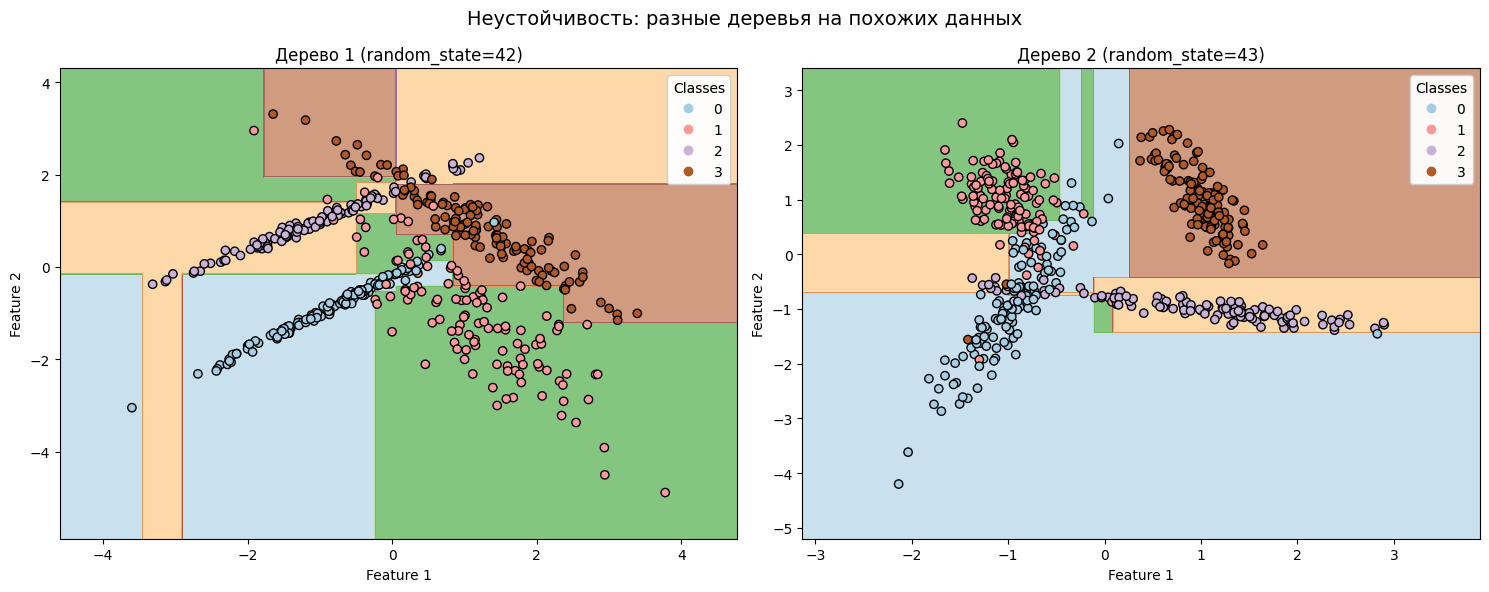

РЕШЕНИЕ ПРОБЛЕМЫ: БЭГГИНГ (BAGGING)
Точность одного дерева: 0.680
Точность ансамбля (Bagging): 0.756
Улучшение: 0.076


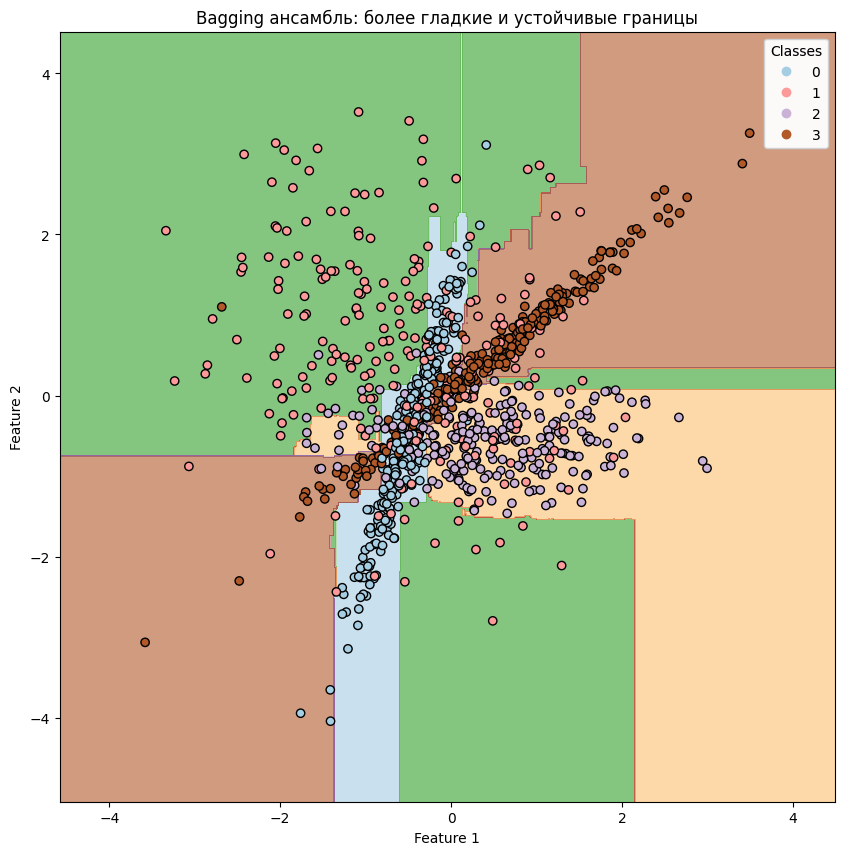

ИЗМЕНЕНИЕ СТРУКТУРЫ ДЕРЕВА ПРИ УДАЛЕНИИ 1% ДАННЫХ
Точность на полных данных: 0.688
Точность после удаления 5% данных: 0.708
Изменение: 0.020

Глубина полного дерева: 4
Глубина дерева после удаления: 4
Количество листьев (полное): 16
Количество листьев (после удаления): 15


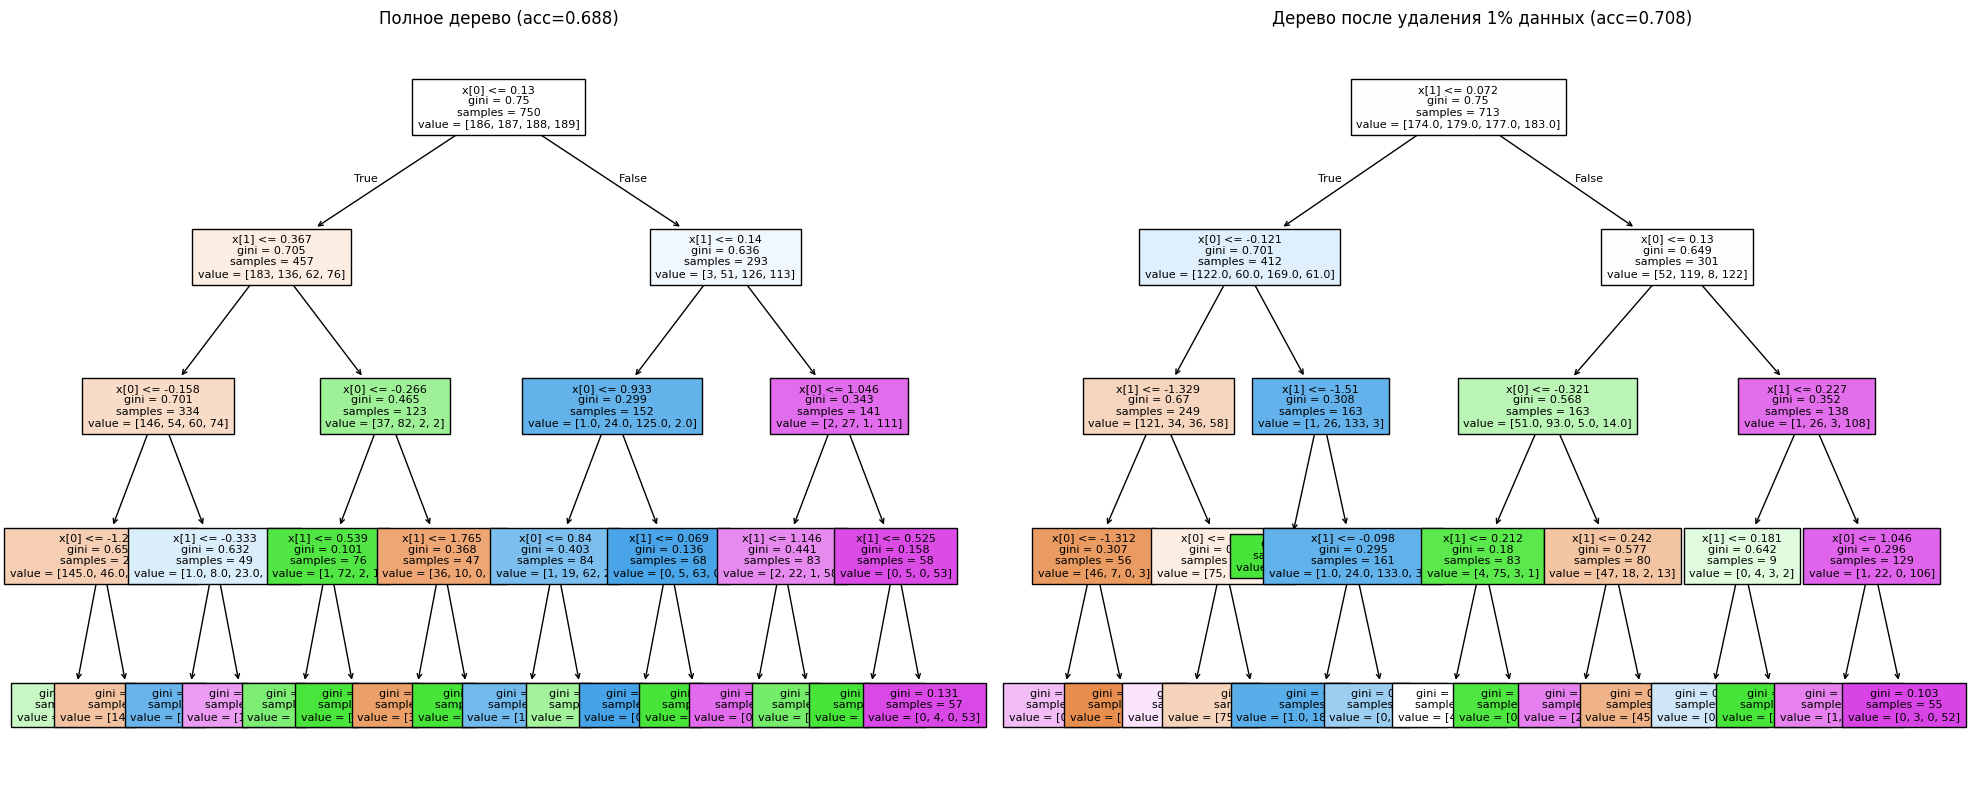

RANDOM FOREST (Bagging + случайные признаки)
Точность Random Forest: 0.748
Улучшение по сравнению с одним деревом: 0.068


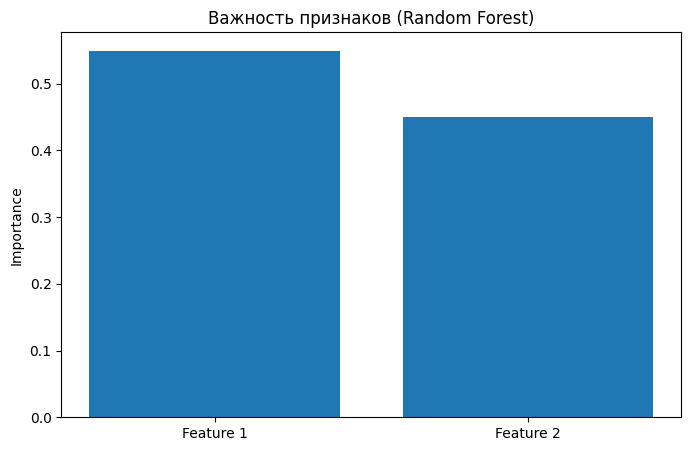

СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
Обычное дерево            Accuracy: 0.680
Pre-pruned дерево         Accuracy: 0.680
Post-pruned дерево        Accuracy: 0.704
Best params дерево        Accuracy: 0.704
Bagging (50 деревьев)     Accuracy: 0.756
Random Forest (100 деревьев) Accuracy: 0.748
ВЫВОДЫ:
Деревья решений неустойчивы к малым изменениям в данных, даже небольшое изменение (удаление 1% данных) может значительно изменить 
структуру дерева. Решения: бэггинг - усреднение нескольких деревьев, Random Forest - бэггинг + случайный выбор признаков, градиентный бустинг (другая техника)
Ансамблевые методы дают более стабильные и точные предсказания. Random Forest показал лучшее качество за счет разнообразия деревьев


In [18]:
print("ДЕМОНСТРАЦИЯ НЕУСТОЙЧИВОСТИ ДЕРЕВЬЕВ РЕШЕНИЙ")

from sklearn.metrics import accuracy_score

X1, y1 = make_classification(
    n_samples=500, 
    n_features=2, 
    n_informative=2,
    n_redundant=0, 
    n_classes=4, 
    n_clusters_per_class=1,
    random_state=42
)

X2, y2 = make_classification(
    n_samples=500, 
    n_features=2, 
    n_informative=2,
    n_redundant=0, 
    n_classes=4, 
    n_clusters_per_class=1,
    random_state=43
)

tree1 = DecisionTreeClassifier(random_state=42, max_depth=5)
tree2 = DecisionTreeClassifier(random_state=42, max_depth=5)

tree1.fit(X1, y1)
tree2.fit(X2, y2)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_decision_boundaries(tree1, X1, y1, ax=axes[0], title="Дерево 1 (random_state=42)")
plot_decision_boundaries(tree2, X2, y2, ax=axes[1], title="Дерево 2 (random_state=43)")

plt.suptitle("Неустойчивость: разные деревья на похожих данных", fontsize=14)
plt.tight_layout()
plt.show()

from sklearn.ensemble import BaggingClassifier

print("РЕШЕНИЕ ПРОБЛЕМЫ: БЭГГИНГ (BAGGING)")

single_tree = DecisionTreeClassifier(random_state=42, max_depth=5)
single_tree.fit(X_train, y_train)
single_accuracy = single_tree.score(X_test, y_test)

bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
bagging_clf.fit(X_train, y_train)
bagging_accuracy = bagging_clf.score(X_test, y_test)

print(f"Точность одного дерева: {single_accuracy:.3f}")
print(f"Точность ансамбля (Bagging): {bagging_accuracy:.3f}")
print(f"Улучшение: {bagging_accuracy - single_accuracy:.3f}")

plt.figure(figsize=(10, 10))
plot_decision_boundaries(bagging_clf, X, y)
plt.title("Bagging ансамбль: более гладкие и устойчивые границы")
plt.show()

print("ИЗМЕНЕНИЕ СТРУКТУРЫ ДЕРЕВА ПРИ УДАЛЕНИИ 1% ДАННЫХ")

tree_full = DecisionTreeClassifier(random_state=42, max_depth=4)
tree_full.fit(X_train, y_train)

np.random.seed(42)
n_remove = int(0.05 * len(X_train))
indices_to_remove = np.random.choice(len(X_train), n_remove, replace=False)

X_train_small = np.delete(X_train, indices_to_remove, axis=0)
y_train_small = np.delete(y_train, indices_to_remove, axis=0)

tree_small = DecisionTreeClassifier(random_state=42, max_depth=4)
tree_small.fit(X_train_small, y_train_small)

acc_full = tree_full.score(X_test, y_test)
acc_small = tree_small.score(X_test, y_test)

print(f"Точность на полных данных: {acc_full:.3f}")
print(f"Точность после удаления 5% данных: {acc_small:.3f}")
print(f"Изменение: {acc_small - acc_full:.3f}")

print(f"\nГлубина полного дерева: {tree_full.get_depth()}")
print(f"Глубина дерева после удаления: {tree_small.get_depth()}")
print(f"Количество листьев (полное): {tree_full.get_n_leaves()}")
print(f"Количество листьев (после удаления): {tree_small.get_n_leaves()}")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
plot_tree(tree_full, filled=True, ax=axes[0], fontsize=8)
axes[0].set_title(f"Полное дерево (acc={acc_full:.3f})")
plot_tree(tree_small, filled=True, ax=axes[1], fontsize=8)
axes[1].set_title(f"Дерево после удаления 1% данных (acc={acc_small:.3f})")
plt.tight_layout()
plt.show()

from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_clf.fit(X_train, y_train)
rf_accuracy = rf_clf.score(X_test, y_test)

print("RANDOM FOREST (Bagging + случайные признаки)")
print(f"Точность Random Forest: {rf_accuracy:.3f}")
print(f"Улучшение по сравнению с одним деревом: {rf_accuracy - single_accuracy:.3f}")

plt.figure(figsize=(8, 5))
plt.bar(['Feature 1', 'Feature 2'], rf_clf.feature_importances_)
plt.title("Важность признаков (Random Forest)")
plt.ylabel("Importance")
plt.show()

print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")

models = {
    "Обычное дерево": single_tree,
    "Pre-pruned дерево": clf_prepruned,
    "Post-pruned дерево": clf_postpruned,
    "Best params дерево": best_clf,
    "Bagging (50 деревьев)": bagging_clf,
    "Random Forest (100 деревьев)": rf_clf
}

for name, model in models.items():
    score = model.score(X_test, y_test)
    print(f"{name:25} Accuracy: {score:.3f}")

print("ВЫВОДЫ:")
print("""Деревья решений неустойчивы к малым изменениям в данных, даже небольшое изменение (удаление 5% данных) может значительно изменить 
структуру дерева. Решения: бэггинг - усреднение нескольких деревьев, Random Forest - бэггинг + случайный выбор признаков, градиентный бустинг (другая техника)
Ансамблевые методы дают более стабильные и точные предсказания. Random Forest показал лучшее качество за счет разнообразия деревьев""")